# ETS (Exponential Smoothing) — Demand Forecasting Notebook



### Cell 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 130)
print("All libraries loaded.")


Mounted at /content/drive
All libraries loaded.


### Cell 2 — Load and clean data

In [2]:
DATA_PATH = '/content/drive/MyDrive/data-2025-11-23.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['ProductId']).copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M')
df['ProductId'] = df['ProductId'].astype(int)
df = df.sort_values(['ProductId', 'Date']).reset_index(drop=True)

TARGET = 'TotalQuantity'
TEST_SIZE = 12
product_ids = sorted(df['ProductId'].unique())

print(f"Shape: {df.shape}")
print(f"Products ({len(product_ids)}): {product_ids}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Shape: (2116, 12)
Products (20): [np.int64(3), np.int64(7), np.int64(11), np.int64(19), np.int64(22), np.int64(28), np.int64(33), np.int64(40), np.int64(44), np.int64(45), np.int64(47), np.int64(61), np.int64(66), np.int64(71), np.int64(75), np.int64(81), np.int64(86), np.int64(88), np.int64(91), np.int64(93)]
Date range: 2017-01-01 00:00:00 to 2025-10-01 00:00:00


### Cell 4 — Transformation analysis per product



In [3]:
transform_config = {}

print(f"{'Product':>8} | {'CV':>6} | {'Skew':>6} | {'Transform':>10}")
print("-" * 40)

for pid in product_ids:
    sub = df[df['ProductId'] == pid][TARGET]
    cv = sub.std() / sub.mean()
    skew = sub.skew()

    if abs(skew) > 0.8:
        t = 'log'
    elif cv > 0.5:
        t = 'sqrt'
    else:
        t = 'none'

    if t == 'log' and sub.min() <= 0:
        t = 'sqrt'

    transform_config[pid] = t
    print(f"{pid:8d} | {cv:6.3f} | {skew:+6.2f} | {t:>10}")

from collections import Counter
print(f"\nSummary: {dict(Counter(transform_config.values()))}")


 Product |     CV |   Skew |  Transform
----------------------------------------
       3 |  0.671 |  +0.35 |       sqrt
       7 |  0.476 |  +1.26 |        log
      11 |  0.428 |  +0.54 |       none
      19 |  0.517 |  +0.38 |       sqrt
      22 |  0.347 |  +0.29 |       none
      28 |  0.351 |  +1.16 |        log
      33 |  0.591 |  +0.66 |       sqrt
      40 |  0.280 |  +0.21 |       none
      44 |  0.348 |  +0.44 |       none
      45 |  0.384 |  +0.62 |       none
      47 |  0.398 |  +1.01 |        log
      61 |  0.350 |  +0.78 |       none
      66 |  0.430 |  +0.68 |       none
      71 |  0.317 |  +0.69 |       none
      75 |  0.298 |  +0.98 |        log
      81 |  0.425 |  +0.70 |       none
      86 |  0.742 |  +1.47 |        log
      88 |  0.291 |  +1.00 |        log
      91 |  0.692 |  +1.58 |        log
      93 |  0.668 |  +0.49 |       sqrt

Summary: {'sqrt': 4, 'log': 7, 'none': 9}


### Cell 5 — Visualize all products after preprocessing

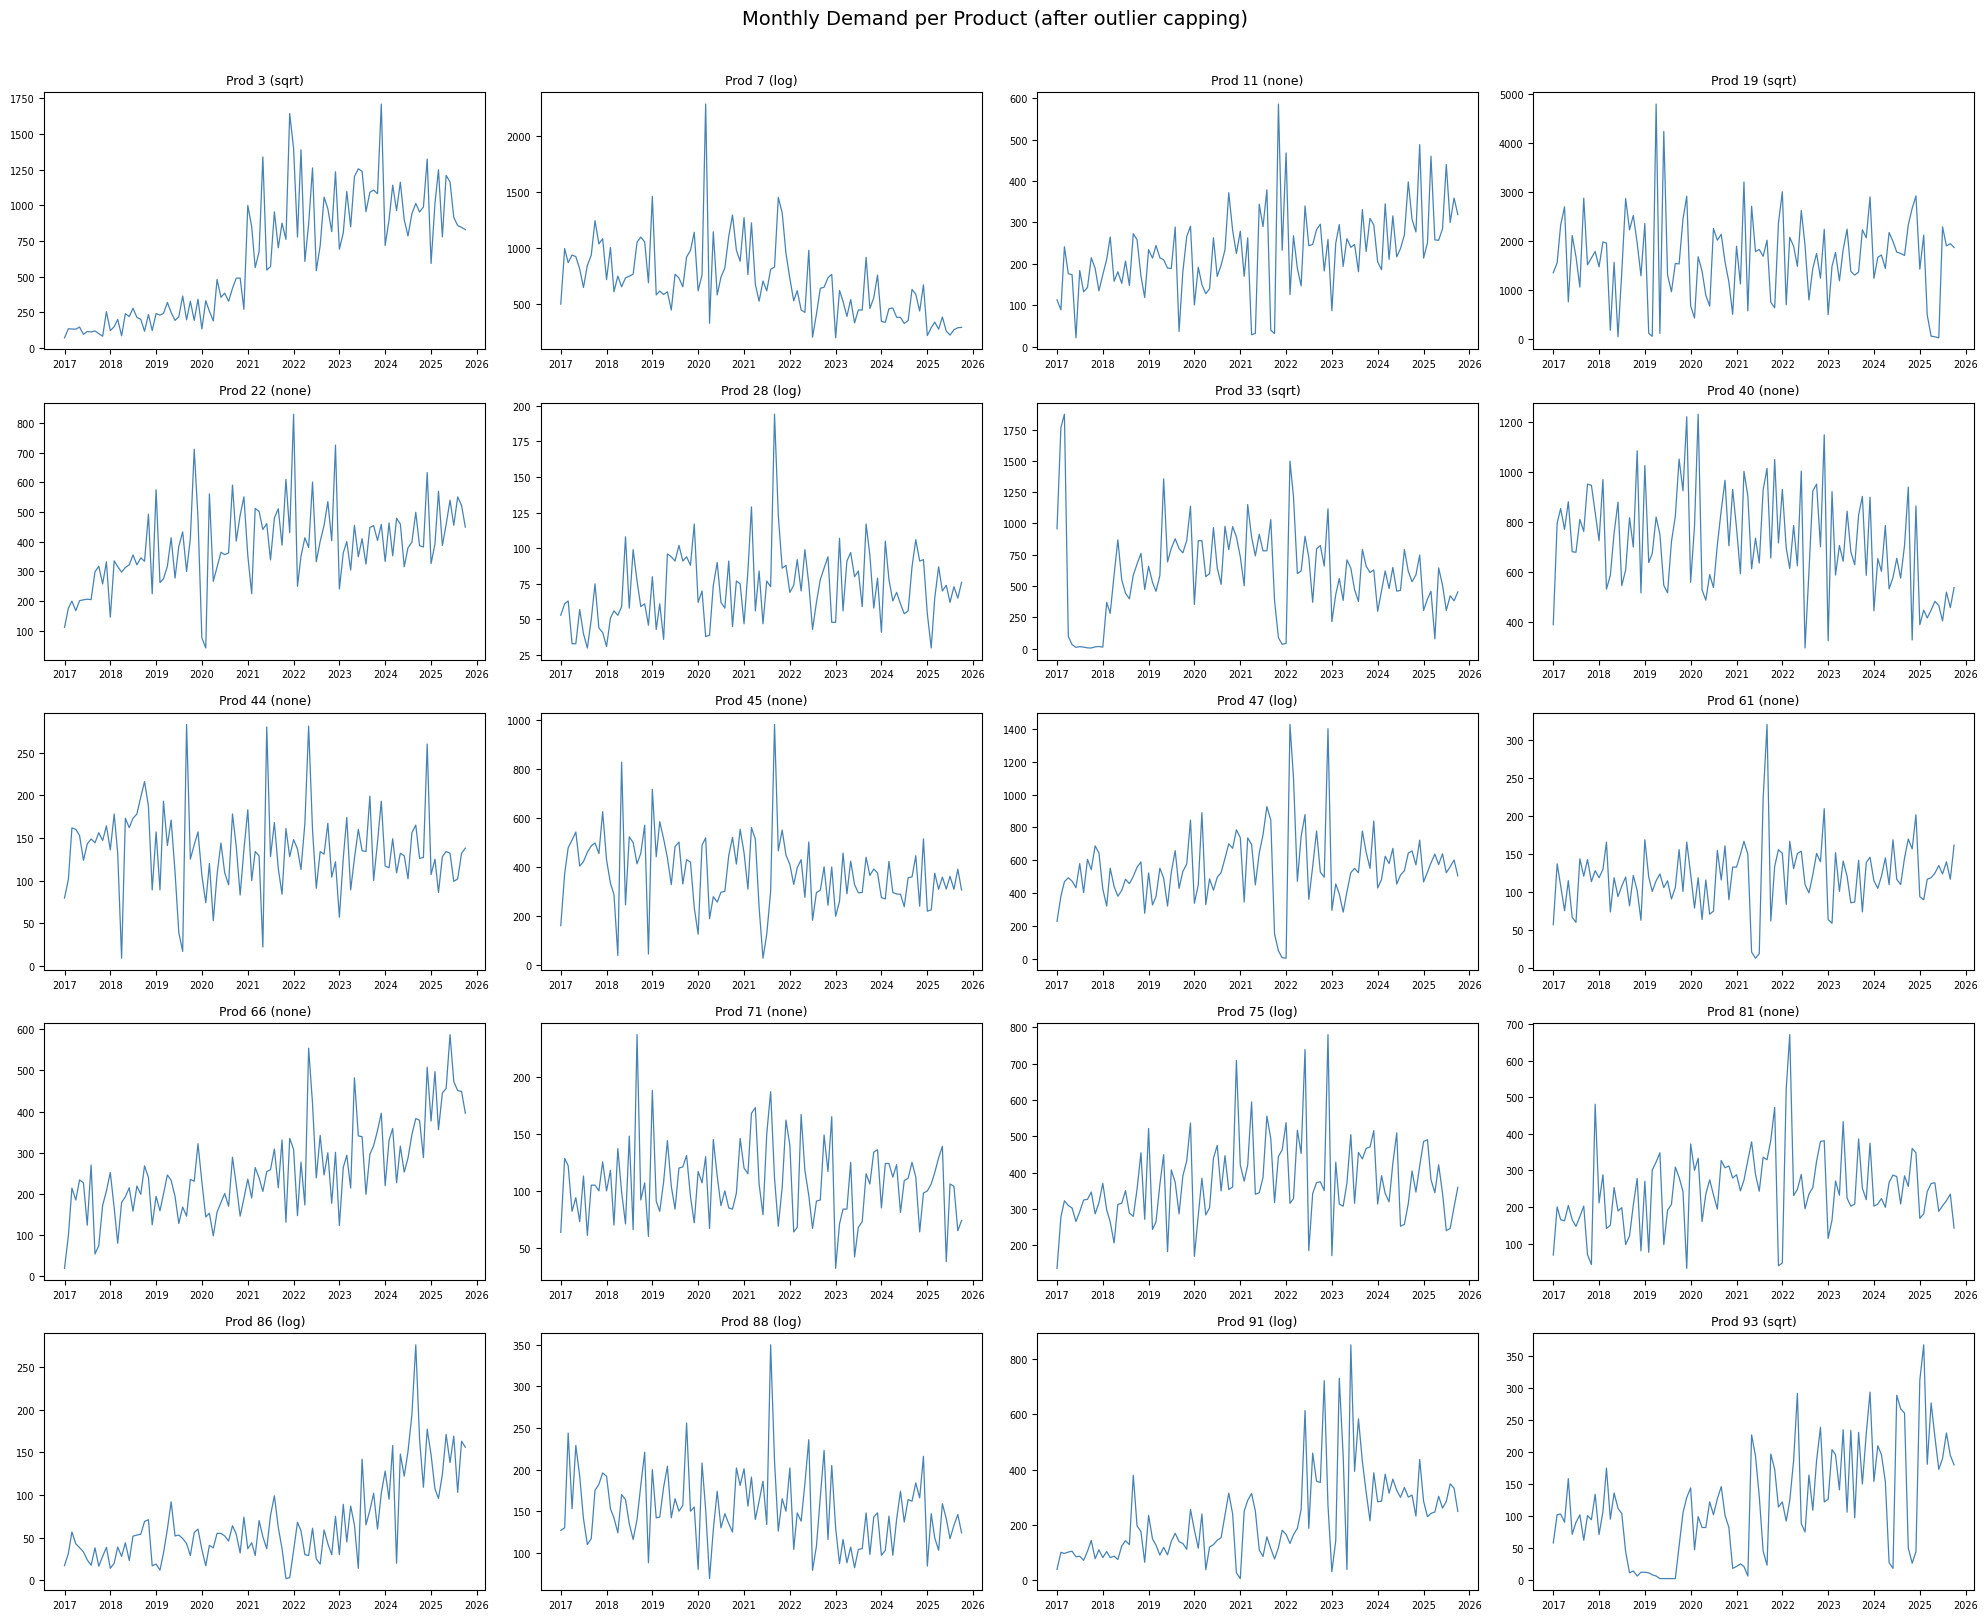

In [4]:
fig, axes = plt.subplots(5, 4, figsize=(20, 16))
for i, pid in enumerate(product_ids):
    sub = df[df['ProductId'] == pid].set_index('Date')[TARGET]
    axes.flatten()[i].plot(sub, lw=0.9, color='steelblue')
    axes.flatten()[i].set_title(f'Prod {pid} ({transform_config[pid]})', fontsize=9)
    axes.flatten()[i].tick_params(labelsize=7)
plt.suptitle('Monthly Demand per Product (after outlier capping)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Cell 6 — Helper functions

In [5]:
def apply_transform(y, method):
    if method == 'log':
        return np.log1p(y)
    elif method == 'sqrt':
        return np.sqrt(y)
    return y.copy()

def inverse_transform(vals, method):
    if method == 'log':
        return np.maximum(np.expm1(vals), 0)
    elif method == 'sqrt':
        return np.maximum(vals ** 2, 0)
    return np.maximum(vals, 0)

def split_train_test(series, test_size=TEST_SIZE):
    if len(series) < 24:
        test_size = min(6, len(series) // 3)
    return series.iloc[:-test_size], series.iloc[-test_size:]

def safe_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Helper functions defined.")


Helper functions defined.


### Cell 7 — Fit ETS for all 20 products (auto-select best configuration)




In [6]:
results = []
all_actual_list = []
all_forecast_list = []

ets_configs = []
for trend in [None, 'add']:
    for seasonal in [None, 'add']:
        for damped in [False, True]:
            if trend is None and damped:
                continue
            ets_configs.append((trend, seasonal, damped))

print(f"Testing {len(ets_configs)} ETS configs per product\n")

for pid in product_ids:
    print(f"{'='*60}")
    print(f"Product {pid}")
    print('='*60)

    sub = df[df['ProductId'] == pid].set_index('Date').sort_index()
    sub = sub[~sub.index.duplicated(keep='first')].asfreq('MS')
    y_raw = sub[TARGET].ffill().bfill() # Raw series, just forward/backfilled

    train_y_raw, test_y_raw = split_train_test(y_raw)

    Q1_train = train_y_raw.quantile(0.25)
    Q3_train = train_y_raw.quantile(0.75)
    IQR_train = Q3_train - Q1_train
    lower_bound = Q1_train - 1.5 * IQR_train
    upper_bound = Q3_train + 1.5 * IQR_train

    train_y_capped = train_y_raw.clip(lower=lower_bound, upper=upper_bound)
    test_y_capped = test_y_raw.clip(lower=lower_bound, upper=upper_bound)

    train_y_smoothed = train_y_capped.rolling(3, center=True).mean().bfill().ffill()

    cv_train = train_y_raw.std() / train_y_raw.mean()
    skew_train = train_y_raw.skew()

    if abs(skew_train) > 0.8:
        current_method_for_fitting = 'log'
    elif cv_train > 0.5:
        current_method_for_fitting = 'sqrt'
    else:
        current_method_for_fitting = 'none'

    if current_method_for_fitting == 'log' and train_y_raw.min() <= 0:
        current_method_for_fitting = 'sqrt'

    train_yt = apply_transform(train_y_smoothed, current_method_for_fitting)

    if train_yt.min() <= 0:
        train_yt = train_yt + abs(train_yt.min()) + 1

    train_y = train_y_capped
    test_y = test_y_capped

    best_mae = np.inf
    best = None

    for trend, seasonal, damped in ets_configs:
        try:
            sp = 12 if seasonal else None
            m = ExponentialSmoothing(
                train_yt, trend=trend, seasonal=seasonal,
                seasonal_periods=sp, damped_trend=damped,
                initialization_method='estimated', use_boxcox=False
            )
            f = m.fit(optimized=True, remove_bias=False)
            fc_t = f.forecast(len(test_y))
            fv_t = f.fittedvalues

            fc = inverse_transform(fc_t, current_method_for_fitting)
            fv = inverse_transform(fv_t, current_method_for_fitting)

            mae = mean_absolute_error(test_y, fc)
            if mae < best_mae:
                best_mae = mae
                best = {
                    'fc': fc, 'fv': fv, 'mae': mae,
                    'rmse': np.sqrt(mean_squared_error(test_y, fc)),
                    'mape': safe_mape(test_y.values, np.array(fc)),
                    'aic': f.aic, 'trend': str(trend),
                    'seasonal': str(seasonal), 'damped': damped
                }
        except:
            continue

    if best:
        b = best
        print(f"  Best: trend={b['trend']}, seasonal={b['seasonal']}, damped={b['damped']}")
        print(f"  Transform used for fitting: {current_method_for_fitting}")
        print(f"  MAE={b['mae']:.2f}  RMSE={b['rmse']:.2f}  MAPE={b['mape']:.1f}%")

        all_actual_list.extend(train_y.values.tolist())
        all_actual_list.extend(test_y.values.tolist())
        all_forecast_list.extend(np.array(b['fv']).tolist())
        all_forecast_list.extend(np.array(b['fc']).tolist())

        results.append({
            'ProductId': pid, 'Trend': b['trend'], 'Seasonal': b['seasonal'],
            'Damped': b['damped'], 'Transform': current_method_for_fitting,
            'MAE': round(b['mae'],2), 'RMSE': round(b['rmse'],2),
            'MAPE': round(b['mape'],1) if not np.isnan(b['mape']) else 'N/A',
            'AIC': round(b['aic'],1), 'Status': 'OK'
        })
    else:
        print("  ALL CONFIGS FAILED")
        results.append({
            'ProductId': pid, 'Trend':'N/A', 'Seasonal':'N/A',
            'Damped':'N/A', 'Transform':current_method_for_fitting,
            'MAE':np.nan, 'RMSE':np.nan, 'MAPE':'N/A',
            'AIC':np.nan, 'Status':'FAILED'
        })

print("\n\nAll 20 products processed.")

Testing 6 ETS configs per product

Product 3
  Best: trend=None, seasonal=add, damped=False
  Transform used for fitting: sqrt
  MAE=175.46  RMSE=214.19  MAPE=20.3%
Product 7
  Best: trend=add, seasonal=add, damped=False
  Transform used for fitting: log
  MAE=123.46  RMSE=135.02  MAPE=41.8%
Product 11
  Best: trend=None, seasonal=add, damped=False
  Transform used for fitting: none
  MAE=54.43  RMSE=64.34  MAPE=17.5%
Product 19
  Best: trend=add, seasonal=add, damped=False
  Transform used for fitting: none
  MAE=794.49  RMSE=1031.46  MAPE=1530.6%
Product 22
  Best: trend=add, seasonal=None, damped=False
  Transform used for fitting: none
  MAE=71.81  RMSE=90.06  MAPE=14.9%
Product 28
  Best: trend=None, seasonal=add, damped=False
  Transform used for fitting: log
  MAE=12.33  RMSE=16.60  MAPE=22.7%
Product 33
  Best: trend=add, seasonal=add, damped=True
  Transform used for fitting: sqrt
  MAE=197.39  RMSE=245.66  MAPE=100.1%
Product 40
  Best: trend=add, seasonal=add, damped=False
 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


  Best: trend=add, seasonal=add, damped=False
  Transform used for fitting: none
  MAE=51.49  RMSE=61.40  MAPE=12.3%
Product 71
  Best: trend=add, seasonal=add, damped=True
  Transform used for fitting: none
  MAE=26.00  RMSE=34.07  MAPE=40.8%
Product 75
  Best: trend=add, seasonal=None, damped=False
  Transform used for fitting: log
  MAE=69.96  RMSE=86.50  MAPE=18.9%
Product 81
  Best: trend=add, seasonal=add, damped=True
  Transform used for fitting: none
  MAE=45.80  RMSE=64.82  MAPE=20.3%
Product 86
  Best: trend=None, seasonal=None, damped=False
  Transform used for fitting: log
  MAE=6.46  RMSE=11.55  MAPE=6.3%
Product 88
  Best: trend=add, seasonal=add, damped=False
  Transform used for fitting: log
  MAE=27.49  RMSE=34.54  MAPE=23.4%
Product 91
  Best: trend=None, seasonal=add, damped=False
  Transform used for fitting: log
  MAE=46.65  RMSE=65.63  MAPE=15.5%
Product 93
  Best: trend=None, seasonal=None, damped=False
  Transform used for fitting: sqrt
  MAE=63.48  RMSE=86.56  

### Cell 8 — Summary table and global metrics

In [13]:
results_df = pd.DataFrame(results)

print("=" * 120)
print("FINAL SUMMARY: ETS Model Performance per Product")
print("=" * 120)
print(results_df.to_string(index=False))

nm = pd.to_numeric(results_df['MAE'], errors='coerce')
nr = pd.to_numeric(results_df['RMSE'], errors='coerce')
print(f"\n--- Aggregate Statistics ---")
print(f"Mean MAE:   {nm.mean():.2f}")
print(f"Median MAE: {nm.median():.2f}")
print(f"Mean RMSE:  {nr.mean():.2f}")
print(f"Median RMSE:{nr.median():.2f}")

# Global metrics
all_actual = np.array(all_actual_list)
all_forecast = np.array(all_forecast_list)

r2 = r2_score(all_actual, all_forecast)
correlation = np.corrcoef(all_actual, all_forecast)[0, 1]
global_mae = mean_absolute_error(all_actual, all_forecast)
global_mse = mean_squared_error(all_actual, all_forecast)
global_rmse = np.sqrt(global_mse)
global_mape = safe_mape(all_actual, all_forecast) # Calculate global MAPE

print("\n\n" + "=" * 60)
print("GLOBAL METRICS (all products combined)")
print("=" * 60)
print(f"# ETS (Exponential Smoothing)")
print(f"# Outlier capping + transformations")
print(f"# Best config auto-selected per product")
print(f"# Number in target = {len(all_actual)}")
print(f"# R2 score      = {r2:.6f}")
print(f"# Correlation   = {correlation:.6f}")
print(f"# MAE score     = {global_mae:.4f}")
print(f"# MSE score     = {global_mse:.4f}")
print(f"# RMSE score    = {global_rmse:.4f}")
print(f"# MAPE score    = {global_mape:.4f}") # Print global MAPE

results_df.to_csv('ets_results.csv', index=False)
print("\nSaved: ets_results.csv")

FINAL SUMMARY: ETS Model Performance per Product
 ProductId Trend Seasonal  Damped Transform    MAE    RMSE   MAPE    AIC Status
         3  None      add   False      sqrt 175.46  214.19   20.3   83.8     OK
         7   add      add   False       log 123.46  135.02   41.8 -373.0     OK
        11  None      add   False      none  54.43   64.34   17.5  713.9     OK
        19   add      add   False      none 794.49 1031.46 1530.6 1134.7     OK
        22   add     None   False      none  71.81   90.06   14.9  742.9     OK
        28  None      add   False       log  12.33   16.60   22.7 -351.8     OK
        33   add      add    True      sqrt 197.39  245.66  100.1  240.2     OK
        40   add      add   False      none 201.94  222.90   46.9  821.7     OK
        44   add      add    True      none  23.23   36.11   17.6  582.9     OK
        45  None      add   False      none  72.41   85.75   23.7  797.8     OK
        47  None     None   False       log  63.25   75.20   11.6 -266.

In [14]:
# EXCLUDE selected products from global metrics
exclude_products = [19]

filtered_actual = []
filtered_forecast = []

idx = 0

for pid in product_ids:
    sub = df[df['ProductId'] == pid]
    n = len(sub)

    actual_segment = all_actual_list[idx:idx+n]
    forecast_segment = all_forecast_list[idx:idx+n]

    if pid not in exclude_products:
        filtered_actual.extend(actual_segment)
        filtered_forecast.extend(forecast_segment)

    idx += n

# Convert to numpy
filtered_actual = np.array(filtered_actual, dtype=float)
filtered_forecast = np.array(filtered_forecast, dtype=float)

# Remove NaNs
mask = ~np.isnan(filtered_actual) & ~np.isnan(filtered_forecast)
filtered_actual = filtered_actual[mask]
filtered_forecast = filtered_forecast[mask]

# Compute metrics
if len(filtered_actual) == 0:
    print("No valid data after filtering.")
else:
    global_r2 = r2_score(filtered_actual, filtered_forecast)
    global_corr = np.corrcoef(filtered_actual, filtered_forecast)[0, 1]
    global_mae = mean_absolute_error(filtered_actual, filtered_forecast)
    global_mse = mean_squared_error(filtered_actual, filtered_forecast)
    global_rmse = np.sqrt(global_mse)
    global_mape = safe_mape(filtered_actual, filtered_forecast) # Calculate global MAPE

    print("\n" + "="*60)
    print("GLOBAL METRICS (EXCLUDING Product 19 ")
    print("="*60)
    print(f"# Number of target points = {len(filtered_actual)}")
    print(f"# R2 score      = {global_r2:.6f}")
    print(f"# Correlation   = {global_corr:.6f}")
    print(f"# MAE score     = {global_mae:.4f}")
    print(f"# MSE score     = {global_mse:.4f}")
    print(f"# RMSE score    = {global_rmse:.4f}")
    print(f"# MAPE score    = {global_mape:.4f}") # Print global MAPE


GLOBAL METRICS (EXCLUDING Product 19 
# Number of target points = 2010
# R2 score      = 0.851921
# Correlation   = 0.923189
# MAE score     = 65.3166
# MSE score     = 11249.6404
# RMSE score    = 106.0643
# MAPE score    = 32.6146


### Cell 9.1 — Global Metrics for Test Set Only

In [15]:
test_actual_list = []
test_forecast_list = []

current_idx = 0
for pid in product_ids:
    sub = df[df['ProductId'] == pid]
    n_total = len(sub)
    test_size_for_product = TEST_SIZE

    # Adjust test_size if product series is too short, similar to split_train_test
    if n_total < 24:
        test_size_for_product = min(6, n_total // 3)

    # Extract only the test portion
    if test_size_for_product > 0:
        test_actual_list.extend(all_actual_list[current_idx + n_total - test_size_for_product : current_idx + n_total])
        test_forecast_list.extend(all_forecast_list[current_idx + n_total - test_size_for_product : current_idx + n_total])

    current_idx += n_total

# Convert to numpy arrays
test_actual = np.array(test_actual_list)
test_forecast = np.array(test_forecast_list)

# Handle potential NaNs, although the original code should have handled them
mask = ~np.isnan(test_actual) & ~np.isnan(test_forecast)
test_actual = test_actual[mask]
test_forecast = test_forecast[mask]

# Calculate global metrics for the test set
if len(test_actual) == 0:
    print("No valid test data to calculate global metrics.")
else:
    global_test_r2 = r2_score(test_actual, test_forecast)
    global_test_correlation = np.corrcoef(test_actual, test_forecast)[0, 1]
    global_test_mae = mean_absolute_error(test_actual, test_forecast)
    global_test_mse = mean_squared_error(test_actual, test_forecast)
    global_test_rmse = np.sqrt(global_test_mse)
    global_test_mape = safe_mape(test_actual, test_forecast) # Calculate global MAPE

    print("\n\n" + "=" * 60)
    print("GLOBAL METRICS (TEST SET ONLY)")
    print("=" * 60)
    print(f"# Number in test target = {len(test_actual)}")
    print(f"# R2 score      = {global_test_r2:.6f}")
    print(f"# Correlation   = {global_test_correlation:.6f}")
    print(f"# MAE score     = {global_test_mae:.4f}")
    print(f"# MSE score     = {global_test_mse:.4f}")
    print(f"# RMSE score    = {global_test_rmse:.4f}")
    print(f"# MAPE score    = {global_test_mape:.4f}") # Print global MAPE



GLOBAL METRICS (TEST SET ONLY)
# Number in test target = 240
# R2 score      = 0.607766
# Correlation   = 0.803661
# MAE score     = 109.0719
# MSE score     = 65013.5421
# RMSE score    = 254.9775
# MAPE score    = 106.5224


### Cell 9.2 — Global Metrics for Test Set Only (Excluding Product 19)

In [16]:
exclude_products_test = [19]

filtered_test_actual_list = []
filtered_test_forecast_list = []

current_idx = 0
for pid in product_ids:
    sub = df[df['ProductId'] == pid]
    n_total = len(sub)
    test_size_for_product = TEST_SIZE

    if n_total < 24:
        test_size_for_product = min(6, n_total // 3)

    # Extract only the test portion
    if test_size_for_product > 0:
        actual_segment = all_actual_list[current_idx + n_total - test_size_for_product : current_idx + n_total]
        forecast_segment = all_forecast_list[current_idx + n_total - test_size_for_product : current_idx + n_total]

        if pid not in exclude_products_test:
            filtered_test_actual_list.extend(actual_segment)
            filtered_test_forecast_list.extend(forecast_segment)

    current_idx += n_total

# Convert to numpy arrays
filtered_test_actual = np.array(filtered_test_actual_list, dtype=float)
filtered_test_forecast = np.array(filtered_test_forecast_list, dtype=float)

# Remove NaNs
mask = ~np.isnan(filtered_test_actual) & ~np.isnan(filtered_test_forecast)
filtered_test_actual = filtered_test_actual[mask]
filtered_test_forecast = filtered_test_forecast[mask]

# Calculate global metrics for the filtered test set
if len(filtered_test_actual) == 0:
    print("No valid test data after filtering.")
else:
    global_filtered_test_r2 = r2_score(filtered_test_actual, filtered_test_forecast)
    global_filtered_test_correlation = np.corrcoef(filtered_test_actual, filtered_test_forecast)[0, 1]
    global_filtered_test_mae = mean_absolute_error(filtered_test_actual, filtered_test_forecast)
    global_filtered_test_mse = mean_squared_error(filtered_test_actual, filtered_test_forecast)
    global_filtered_test_rmse = np.sqrt(global_filtered_test_mse)
    global_filtered_test_mape = safe_mape(filtered_test_actual, filtered_test_forecast) # Calculate global MAPE

    print("\n" + "="*60)
    print("GLOBAL METRICS (TEST SET ONLY, EXCLUDING Product 19)")
    print("="*60)
    print(f"# Number in filtered test target = {len(filtered_test_actual)}")
    print(f"# R2 score      = {global_filtered_test_r2:.6f}")
    print(f"# Correlation   = {global_filtered_test_correlation:.6f}")
    print(f"# MAE score     = {global_filtered_test_mae:.4f}")
    print(f"# MSE score     = {global_filtered_test_mse:.4f}")
    print(f"# RMSE score    = {global_filtered_test_rmse:.4f}")
    print(f"# MAPE score    = {global_filtered_test_mape:.4f}") # Print global MAPE


GLOBAL METRICS (TEST SET ONLY, EXCLUDING Product 19)
# Number in filtered test target = 228
# R2 score      = 0.768007
# Correlation   = 0.891277
# MAE score     = 72.9976
# MSE score     = 12439.9434
# RMSE score    = 111.5345
# MAPE score    = 31.5709


### Cell 9 — Actual vs Forecast plots

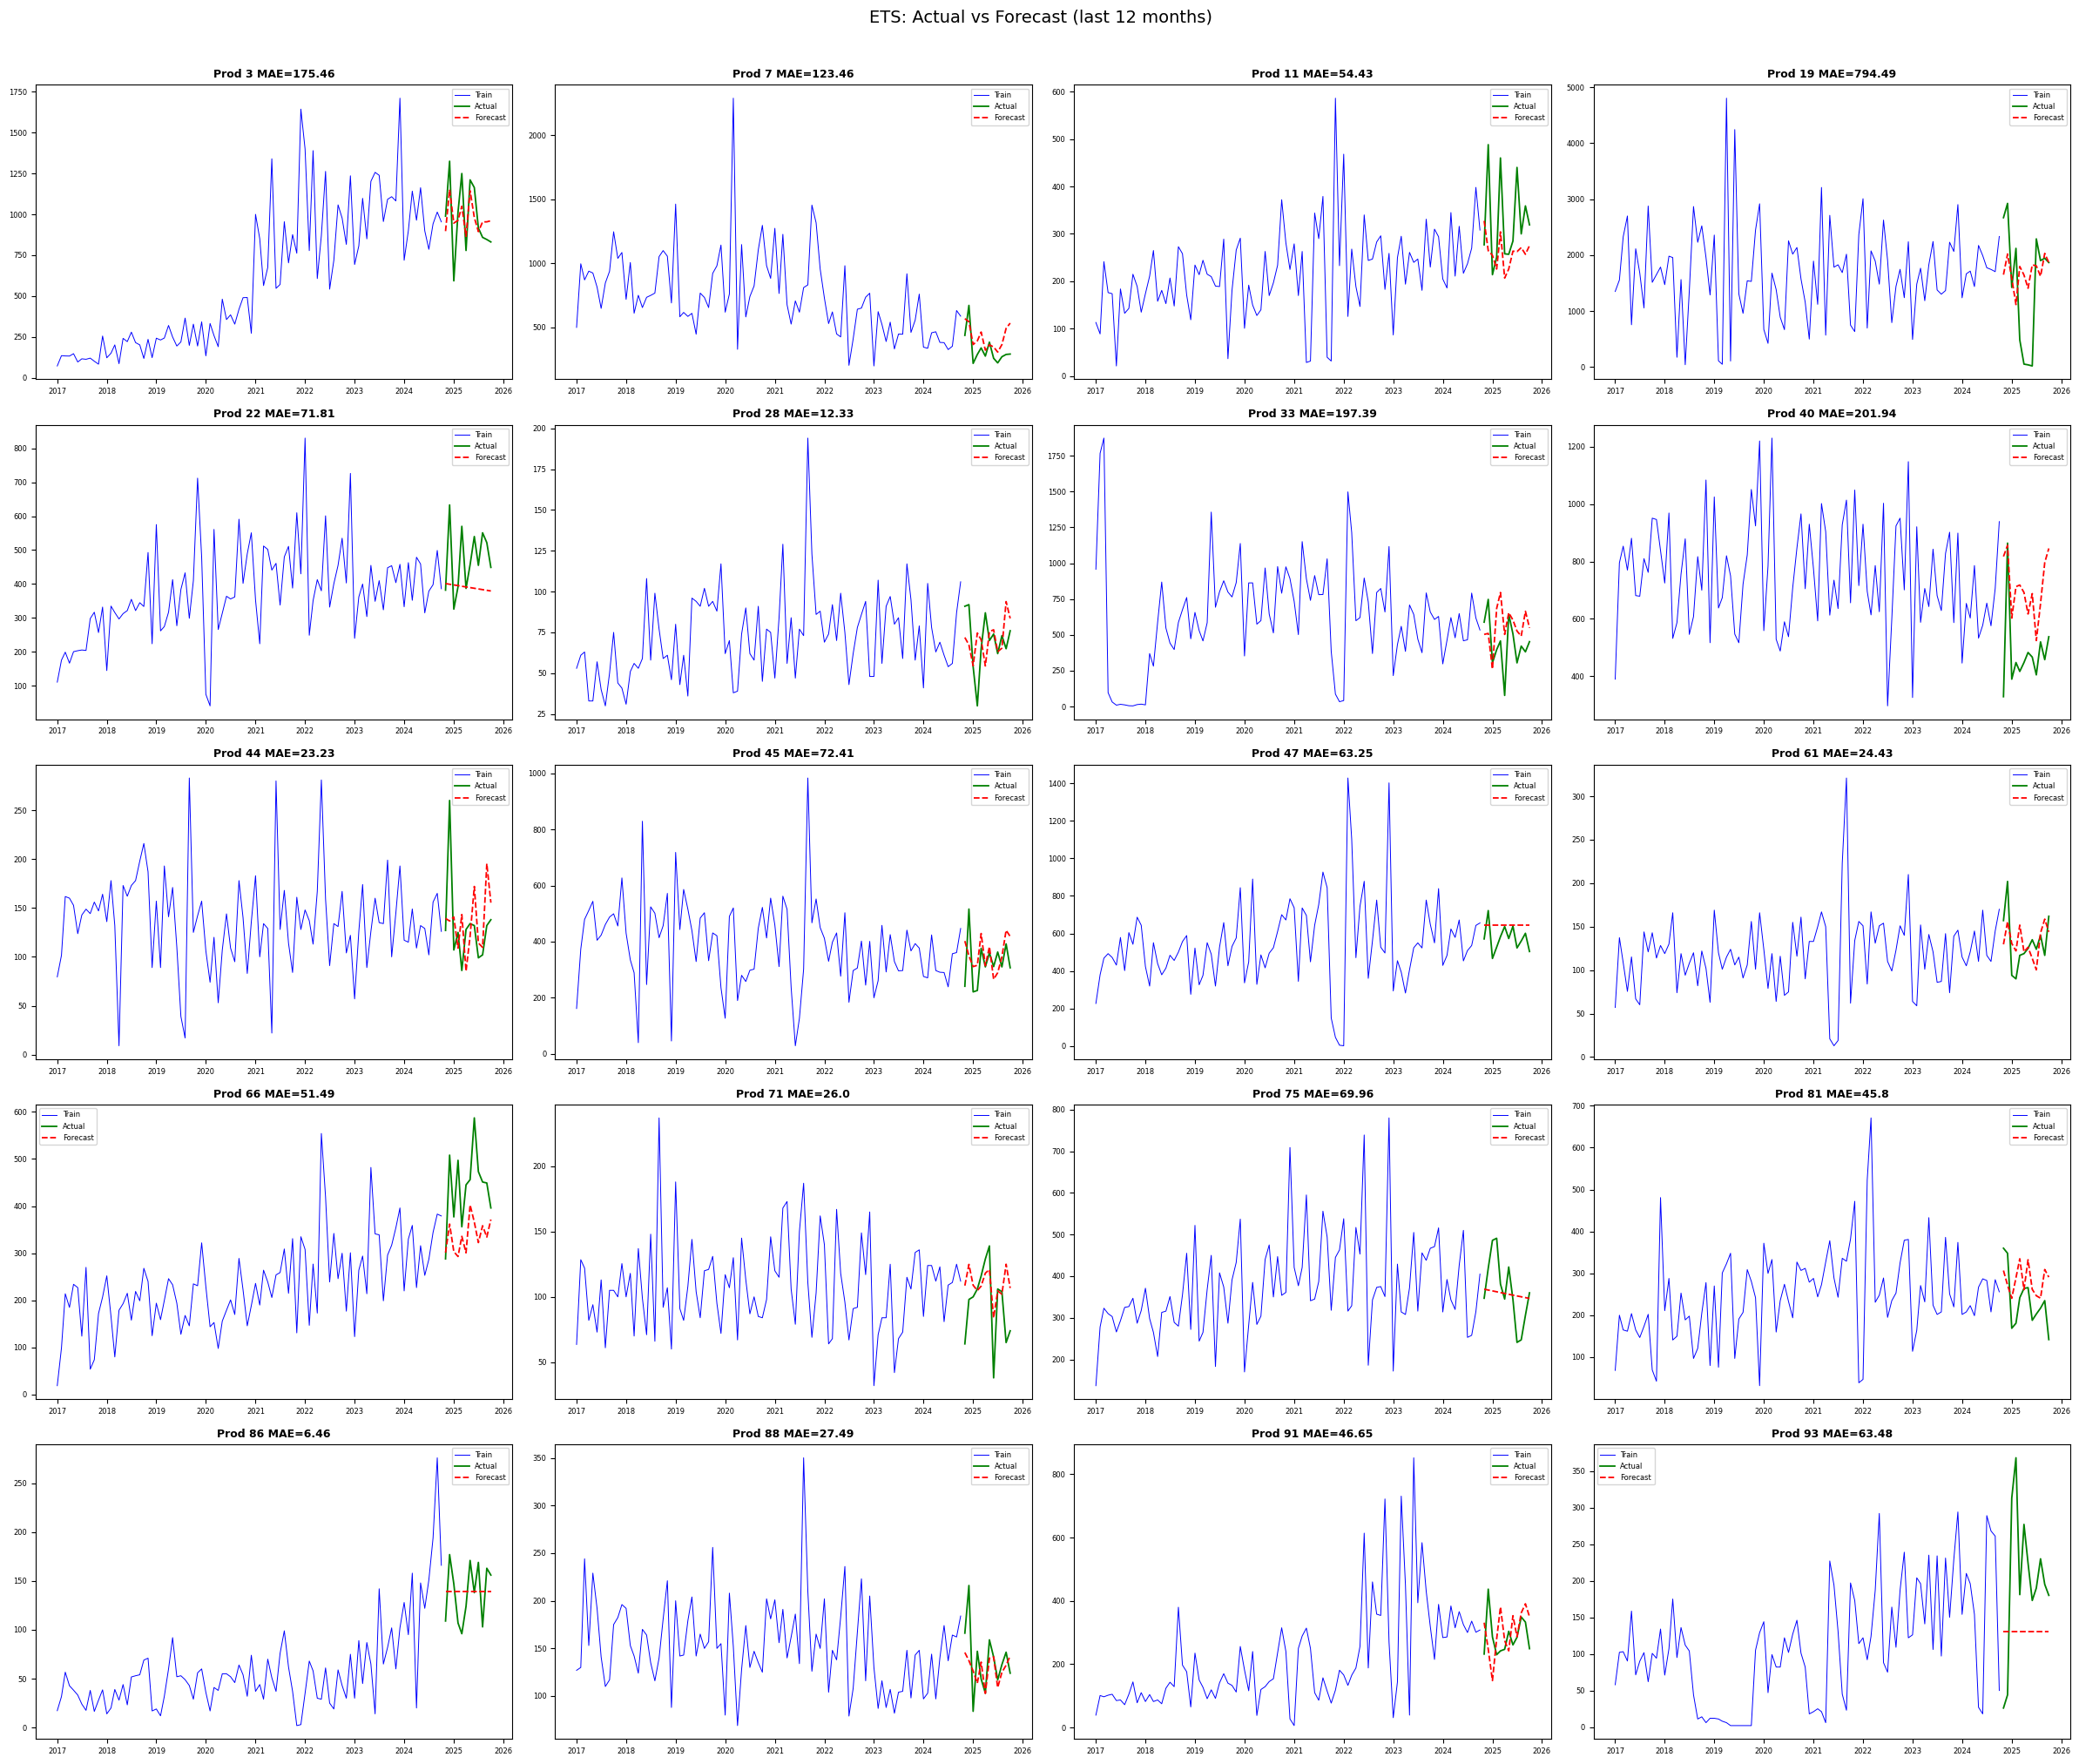

In [10]:
fig, axes = plt.subplots(5, 4, figsize=(24, 20))

for i, pid in enumerate(product_ids):
    ax = axes.flatten()[i]
    sub = df[df['ProductId']==pid].set_index('Date').sort_index()
    sub = sub[~sub.index.duplicated(keep='first')].asfreq('MS')
    y = sub[TARGET].ffill().bfill()

    method = transform_config[pid]
    y_t = apply_transform(y, method)
    if y_t.min() <= 0:
        y_t = y_t + abs(y_t.min()) + 1

    train_y, test_y = split_train_test(y)
    train_yt, _ = split_train_test(y_t)

    r = results_df[results_df['ProductId']==pid].iloc[0]
    trend = None if r['Trend']=='None' else r['Trend']
    seasonal = None if r['Seasonal']=='None' else r['Seasonal']
    sp = 12 if seasonal else None

    try:
        m = ExponentialSmoothing(train_yt, trend=trend, seasonal=seasonal,
            seasonal_periods=sp, damped_trend=r['Damped'],
            initialization_method='estimated')
        f = m.fit(optimized=True)
        fc = inverse_transform(f.forecast(len(test_y)), method)

        ax.plot(train_y.index, train_y, 'b-', lw=0.7, label='Train')
        ax.plot(test_y.index, test_y, 'g-', lw=1.3, label='Actual')
        ax.plot(test_y.index, fc, 'r--', lw=1.3, label='Forecast')
        ax.set_title(f'Prod {pid} MAE={r["MAE"]}', fontsize=9, fontweight='bold')
        ax.legend(fontsize=6)
    except:
        ax.set_title(f'Prod {pid} Error', fontsize=9)
    ax.tick_params(labelsize=6)

plt.suptitle('ETS: Actual vs Forecast (last 12 months)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ets_forecast_all.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell 10 — Residual diagnostics

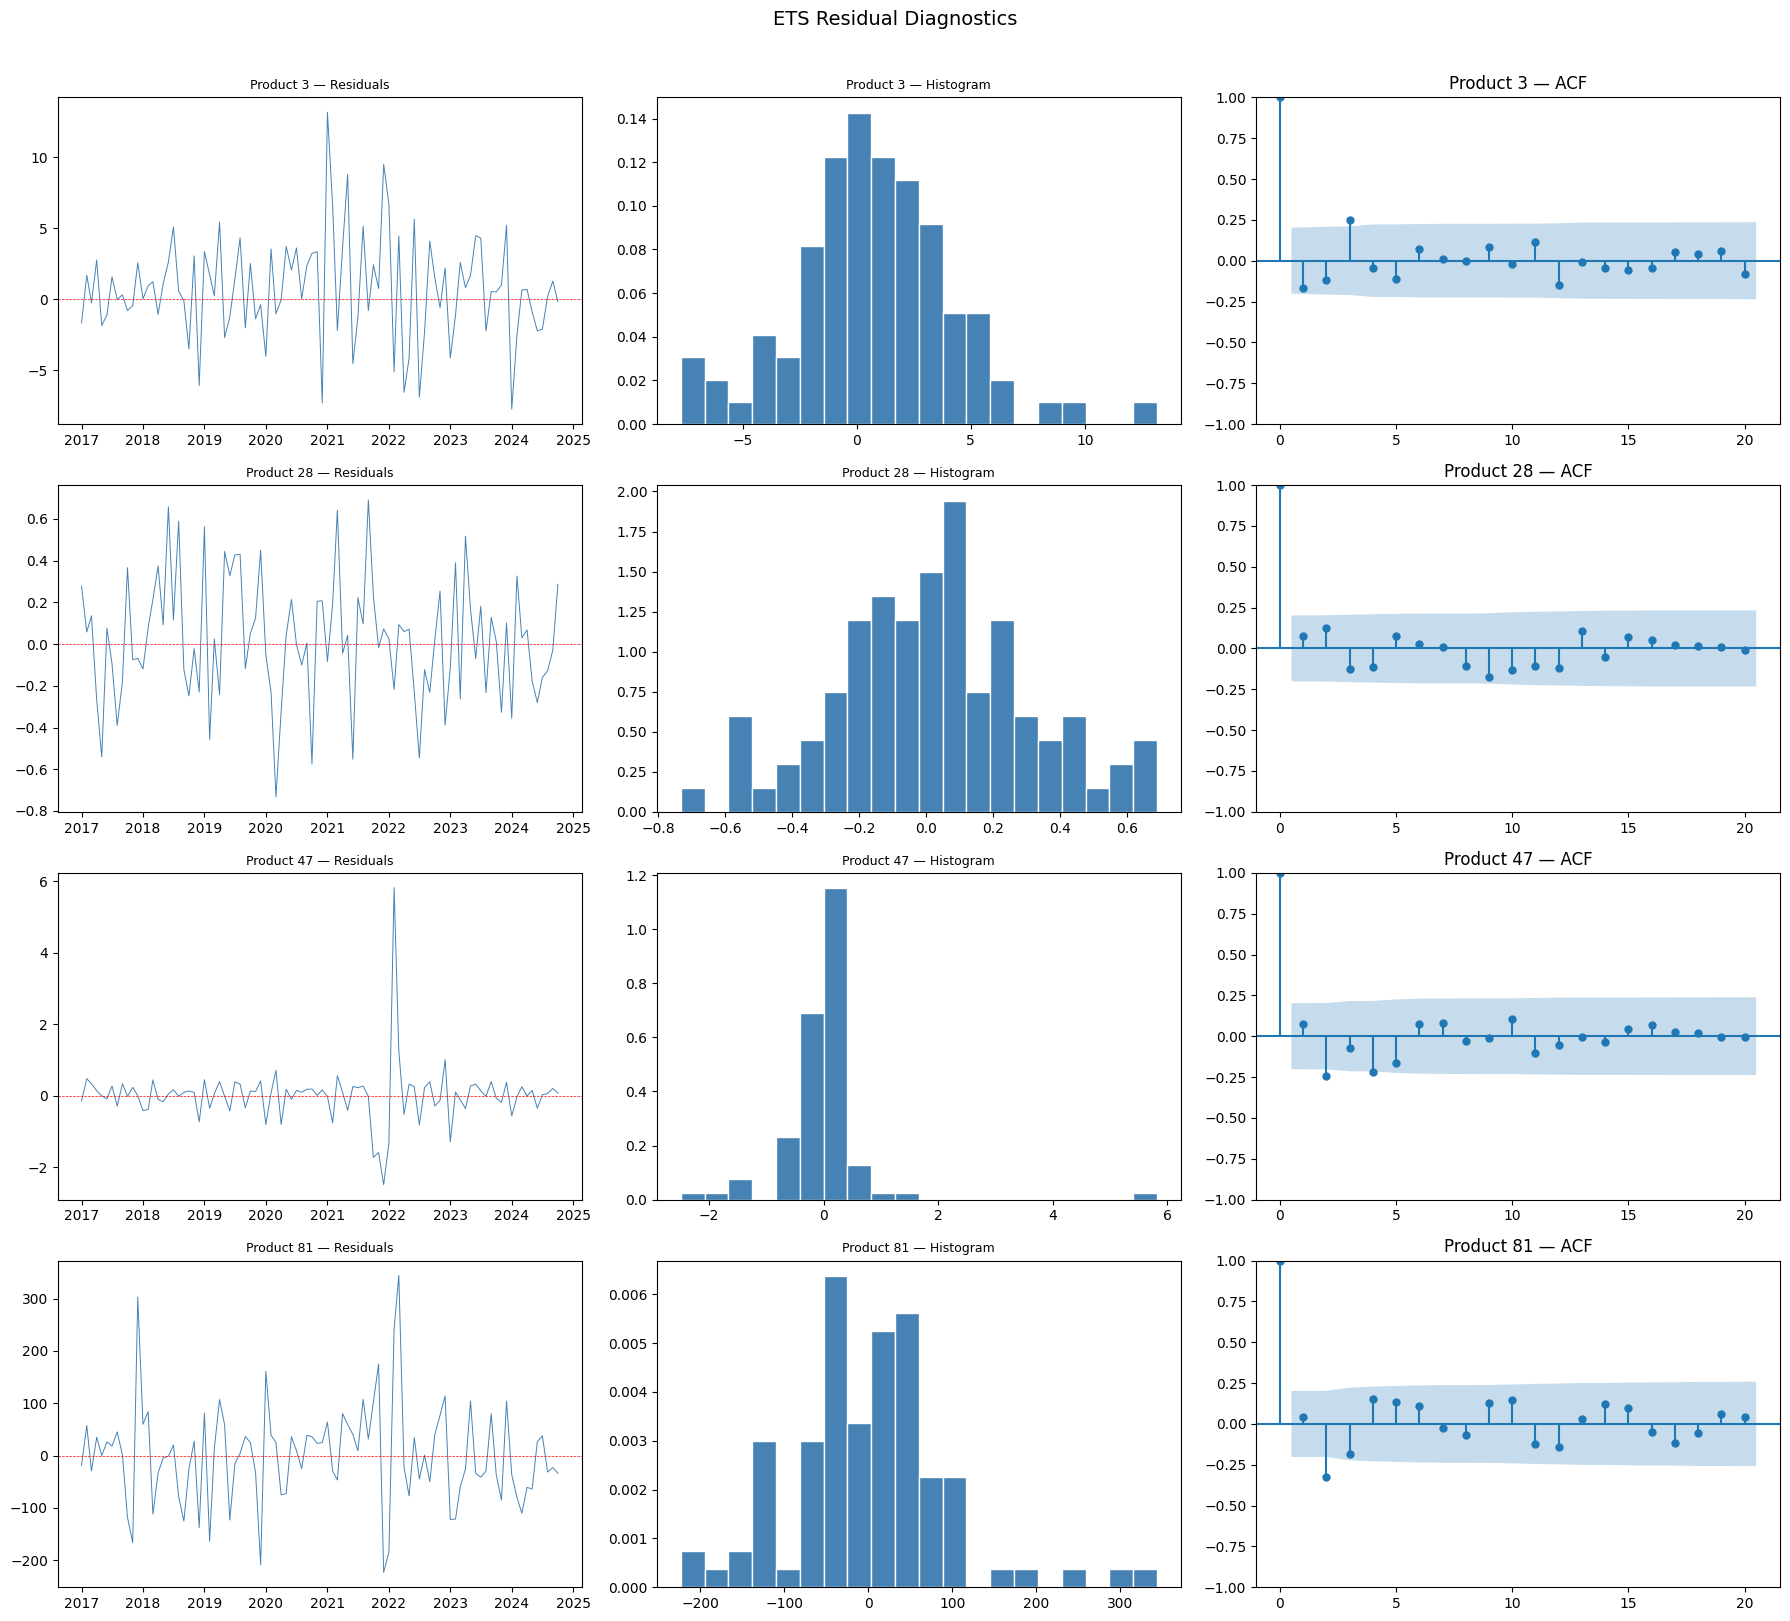

In [11]:
example_pids = [product_ids[0], product_ids[5], product_ids[10], product_ids[15]]
fig, axes = plt.subplots(len(example_pids), 3, figsize=(18, 4*len(example_pids)))

for i, pid in enumerate(example_pids):
    sub = df[df['ProductId']==pid].set_index('Date').sort_index()
    sub = sub[~sub.index.duplicated(keep='first')].asfreq('MS')
    y = sub[TARGET].ffill().bfill()
    y_t = apply_transform(y, transform_config[pid])
    if y_t.min() <= 0: y_t = y_t + abs(y_t.min()) + 1
    train_yt, _ = split_train_test(y_t)

    r = results_df[results_df['ProductId']==pid].iloc[0]
    trend = None if r['Trend']=='None' else r['Trend']
    seasonal = None if r['Seasonal']=='None' else r['Seasonal']
    sp = 12 if seasonal else None

    try:
        m = ExponentialSmoothing(train_yt, trend=trend, seasonal=seasonal,
            seasonal_periods=sp, damped_trend=r['Damped'],
            initialization_method='estimated')
        f = m.fit(optimized=True)
        resid = f.resid

        axes[i,0].plot(resid, color='steelblue', lw=0.7)
        axes[i,0].axhline(0, color='red', ls='--', lw=0.5)
        axes[i,0].set_title(f'Product {pid} — Residuals', fontsize=9)

        axes[i,1].hist(resid.dropna(), bins=20, color='steelblue', edgecolor='white', density=True)
        axes[i,1].set_title(f'Product {pid} — Histogram', fontsize=9)

        plot_acf(resid.dropna(), ax=axes[i,2], lags=20, title=f'Product {pid} — ACF')
    except:
        axes[i,0].set_title(f'Product {pid} — Error', fontsize=9)

plt.suptitle('ETS Residual Diagnostics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
